# Support Vector Machine Assignment — Mushroom Classification

## Objective
The objective of this assignment is to apply **Support Vector Machine (SVM)** classification on the Mushroom dataset.

This notebook includes:

1. Data loading  
2. Exploratory Data Analysis (EDA)  
3. Data visualization  
4. Data preprocessing  
5. Categorical encoding  
6. Train-test split  
7. Basic SVM model  
8. Model evaluation  
9. Visualization of SVM results  
10. Hyperparameter tuning  
11. Comparison of SVM kernels  
12. Strengths and weaknesses of SVM  
13. Practical implications  
14. Final conclusion

## 2. Import Required Libraries

In [25]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load the Mushroom Dataset

In [26]:
df = pd.read_csv("mushroom.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (2000, 26)


,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


## 4. Dataset Information

The target column is:

- `class`

The dataset contains mushroom characteristics such as cap shape, cap color, odor, gill features, population, habitat, stalk measurements, and class label.

In [27]:
print("Dataset Information:")
df.info()

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   

## 5. Remove Unnecessary Column

The column `Unnamed: 0` looks like an index column, so we remove it.

In [28]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Shape after dropping unnecessary column:", df.shape)
display(df.head())

Shape after dropping unnecessary column: (2000, 25)


,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


## 6. Missing Values and Duplicate Check

In [29]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicate rows if present
df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)

Missing Values:
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64

Duplicate Rows: 1024

Shape after removing duplicates: (976, 25)


## 7. Summary Statistics

In [30]:
print("Numerical Summary:")
display(df.describe())

print("Categorical Summary:")
display(df.describe(include="object"))

Numerical Summary:


,stalk_height,cap_diameter
count,976.000000,976.000000
mean,8.524684,12.598566
std,3.703043,6.987077
min,2.000000,1.000000
25%,5.326820,6.141161
50%,8.367245,12.626094
75%,11.758624,18.559780
max,15.095066,25.000054


Categorical Summary:


,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class
count,976,976,976,976,976,976,976,976,976,976,...,976,976,976,976,976,976,976,976,976,976
unique,5,4,9,2,9,4,3,2,12,2,...,9,9,2,4,3,8,9,6,7,2
top,sunken,scaly,brown,yes,foul,free,crowded,narrow,green,enlarging,...,brown,yellow,universal,white,none,sheathing,brown,abundant,urban,poisonous
freq,216,292,127,502,126,270,330,498,96,524,...,127,118,500,273,342,135,122,176,153,618


# Task 1: Exploratory Data Analysis

## 8. Class Distribution

This shows whether the dataset is balanced or imbalanced.

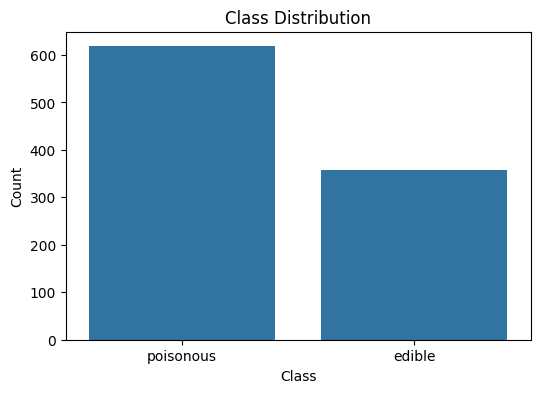

class
poisonous    618
edible       358
Name: count, dtype: int64

Class Percentage:
class
poisonous    63.319672
edible       36.680328
Name: proportion, dtype: float64


In [31]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="class")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(df["class"].value_counts())
print("\nClass Percentage:")
print(df["class"].value_counts(normalize=True) * 100)

## 9. Categorical Feature Distributions

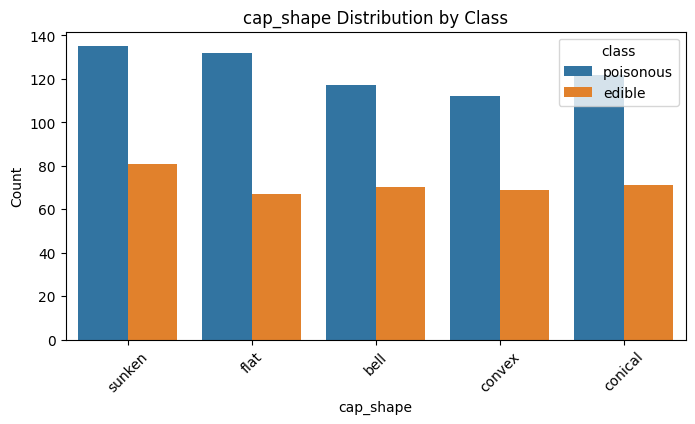

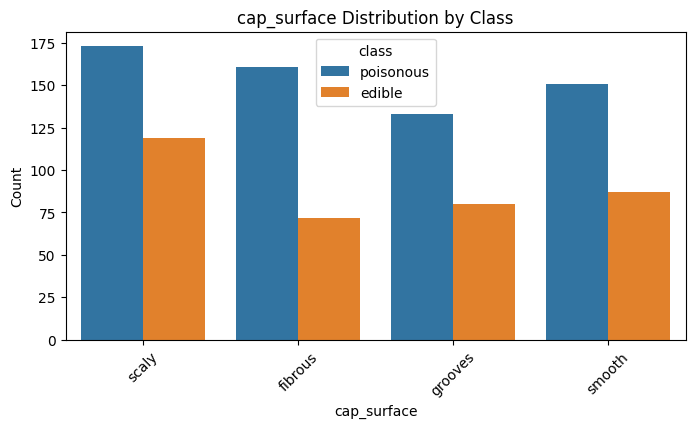

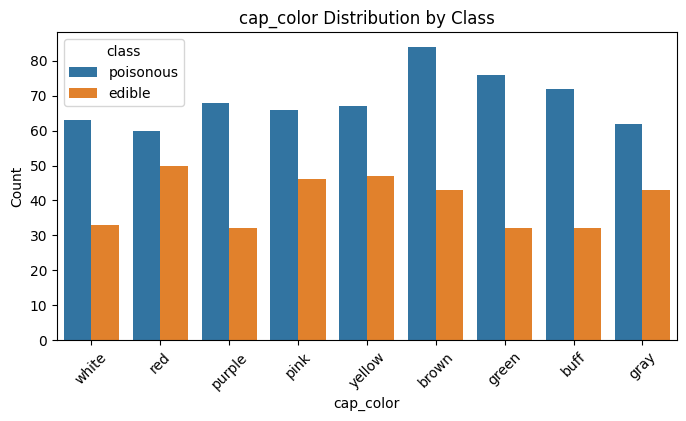

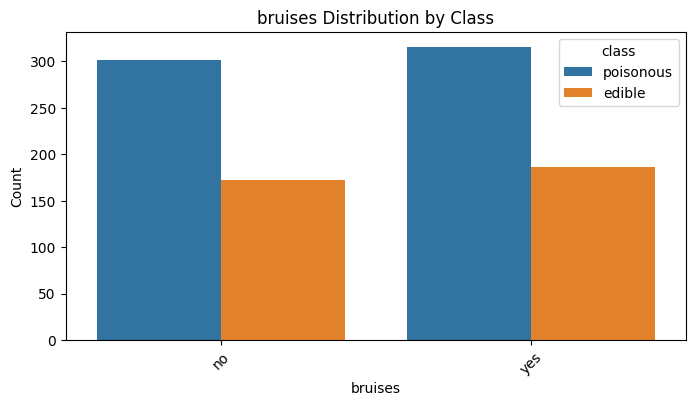

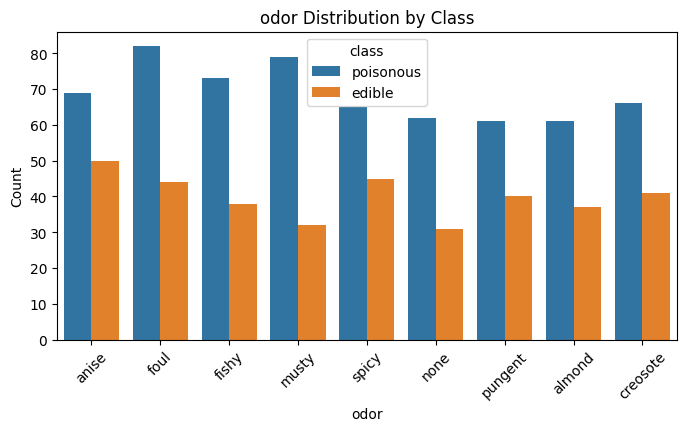

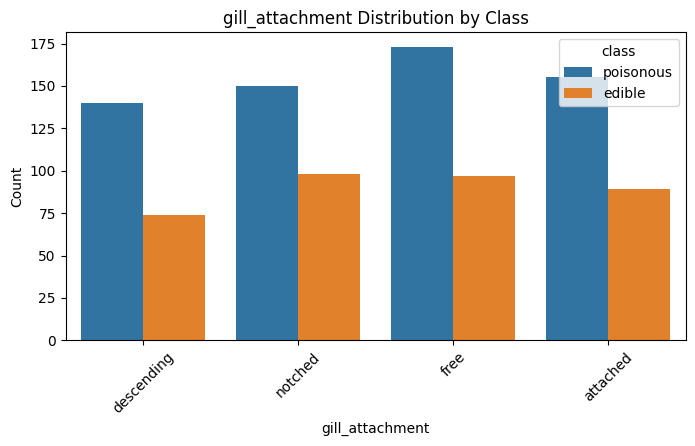

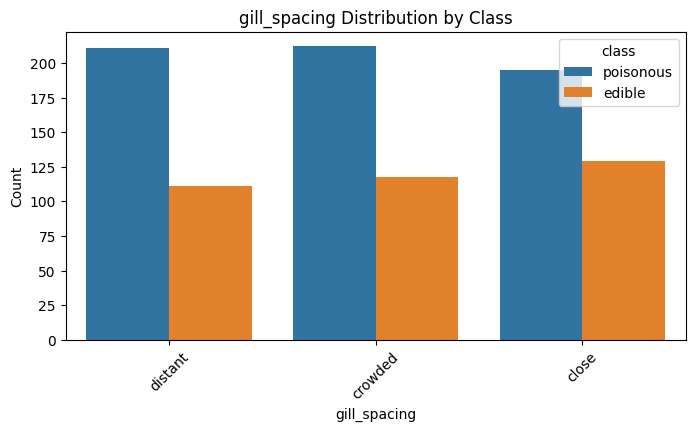

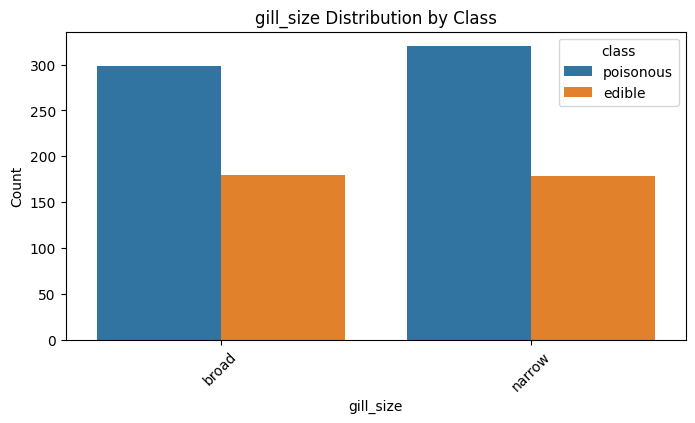

In [32]:
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
categorical_columns.remove("class")

for col in categorical_columns[:8]:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue="class")
    plt.title(f"{col} Distribution by Class")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

## 10. Numerical Feature Distributions

Numerical Columns: ['stalk_height', 'cap_diameter']


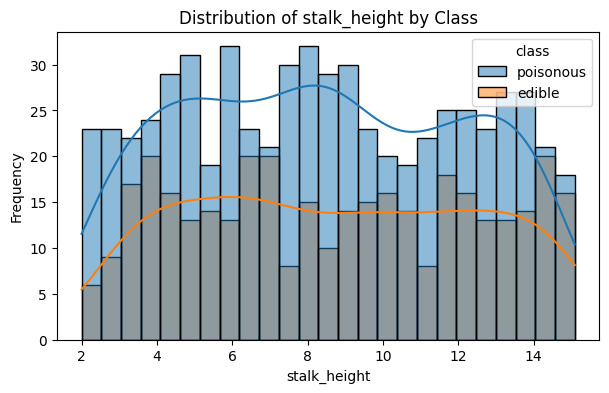

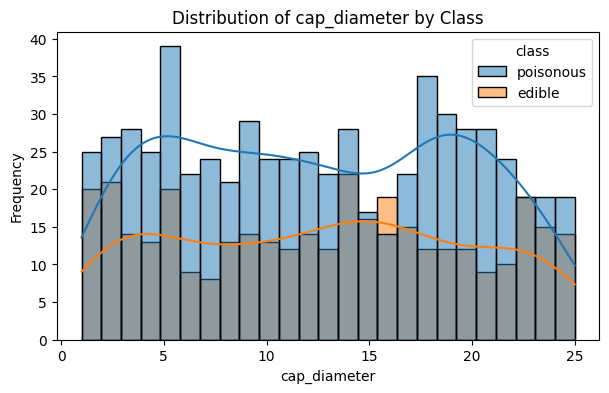

In [33]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numerical Columns:", numerical_columns)

for col in numerical_columns:
    plt.figure(figsize=(7,4))
    sns.histplot(data=df, x=col, hue="class", kde=True, bins=25)
    plt.title(f"Distribution of {col} by Class")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## 11. Boxplots for Numerical Features

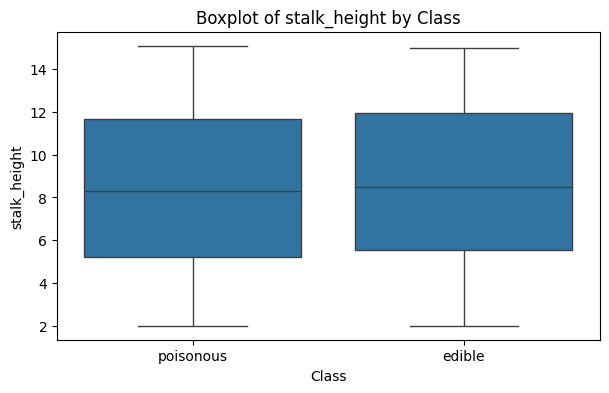

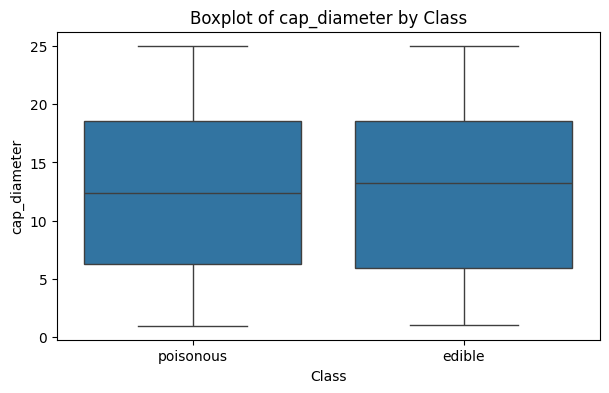

In [34]:
for col in numerical_columns:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x="class", y=col)
    plt.title(f"Boxplot of {col} by Class")
    plt.xlabel("Class")
    plt.ylabel(col)
    plt.show()

## 12. Correlation Analysis

Since most variables are categorical, we first encode them temporarily and then calculate correlation.

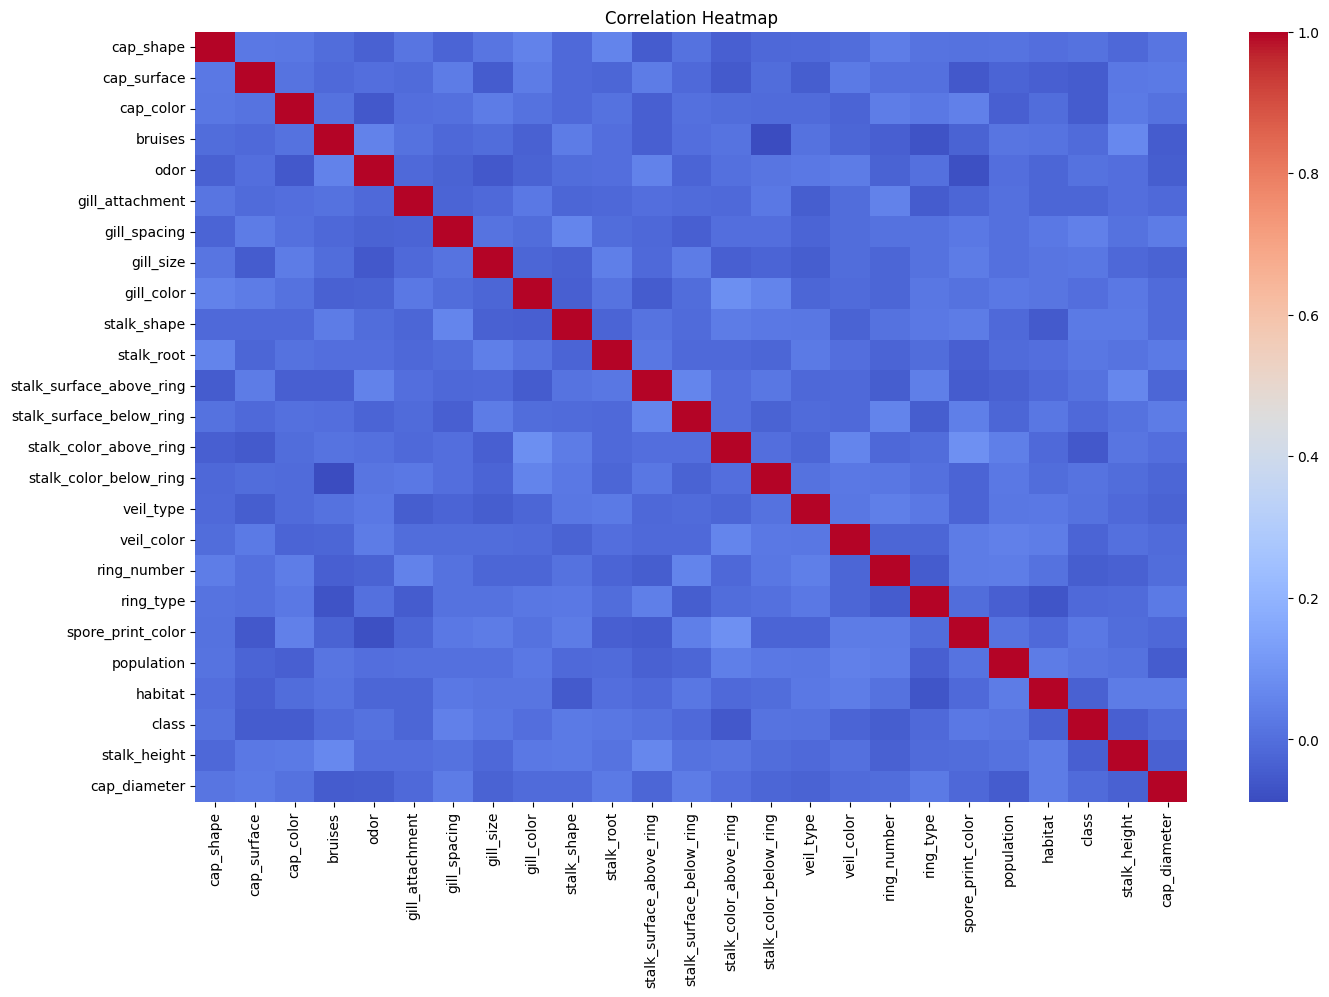

In [35]:
df_encoded_for_corr = df.copy()

label_encoders_corr = {}

for col in df_encoded_for_corr.columns:
    if df_encoded_for_corr[col].dtype == "object":
        le = LabelEncoder()
        df_encoded_for_corr[col] = le.fit_transform(df_encoded_for_corr[col])
        label_encoders_corr[col] = le

plt.figure(figsize=(16,10))
corr_matrix = df_encoded_for_corr.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# Task 2: Data Preprocessing

## 13. Encode Categorical Variables

SVM requires numerical input. Therefore, categorical variables are encoded using one-hot encoding.

The target column `class` is encoded using LabelEncoder.

In [36]:
X = df.drop(columns=["class"])
y = df["class"]

# One-hot encode input features
X_encoded = pd.get_dummies(X, drop_first=True)

# Encode target variable
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Target Classes:", target_encoder.classes_)
print("Encoded Target Sample:", y_encoded[:10])

print("Original Feature Shape:", X.shape)
print("Encoded Feature Shape:", X_encoded.shape)

display(X_encoded.head())

Target Classes: ['edible' 'poisonous']
Encoded Target Sample: [1 0 1 1 1 1 1 1 0 1]
Original Feature Shape: (976, 24)
Encoded Feature Shape: (976, 104)


,stalk_height,cap_diameter,cap_shape_conical,cap_shape_convex,cap_shape_flat,cap_shape_sunken,cap_surface_grooves,cap_surface_scaly,cap_surface_smooth,cap_color_buff,...,population_numerous,population_scattered,population_several,population_solitary,habitat_leaves,habitat_meadows,habitat_paths,habitat_urban,habitat_waste,habitat_woods
0,14.276173,5.054983,False,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
1,3.952715,19.068319,False,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
2,9.054265,7.205884,False,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,5.226499,20.932692,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,14.037532,12.545245,False,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


## 14. Train-Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (780, 104)
X_test shape: (196, 104)
y_train shape: (780,)
y_test shape: (196,)


## 15. Feature Scaling

In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


# Task 4: SVM Implementation

## 16. Basic SVM Classifier

We start with an SVM model using the RBF kernel.

In [39]:
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)

print("Basic SVM model trained successfully.")

Basic SVM model trained successfully.


## 17. Basic SVM Model Evaluation

In [40]:
def evaluate_classifier(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"Evaluation Metrics for {model_name}")
    print("-" * 45)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=target_encoder.classes_, zero_division=0))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

results = []

results.append(evaluate_classifier(y_test, y_pred, "Basic SVM - RBF Kernel"))

Evaluation Metrics for Basic SVM - RBF Kernel
---------------------------------------------
Accuracy : 0.6276
Precision: 0.3991
Recall   : 0.6276
F1 Score : 0.4879

Classification Report:
              precision    recall  f1-score   support

      edible       0.00      0.00      0.00        72
   poisonous       0.63      0.99      0.77       124

    accuracy                           0.63       196
   macro avg       0.32      0.50      0.39       196
weighted avg       0.40      0.63      0.49       196



## 18. Confusion Matrix

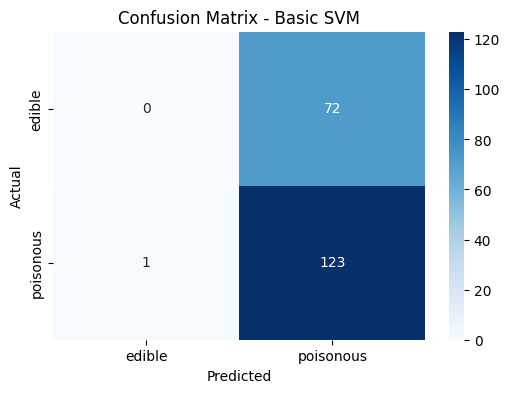

In [41]:
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title("Confusion Matrix - Basic SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Task 5: Visualization of SVM Results

To visualize SVM classification results, high-dimensional encoded data is reduced to two dimensions using PCA.

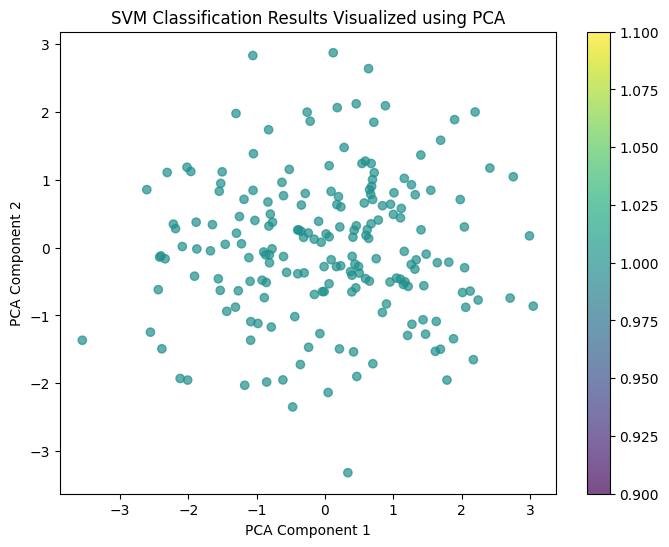

In [42]:
pca = PCA(n_components=2, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

svm_pca_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_pca_model.fit(X_train_pca, y_train)

pca_pred = svm_pca_model.predict(X_test_pca)

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=pca_pred,
    alpha=0.7
)
plt.title("SVM Classification Results Visualized using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter)
plt.show()

## 19. Decision Boundary Visualization using PCA

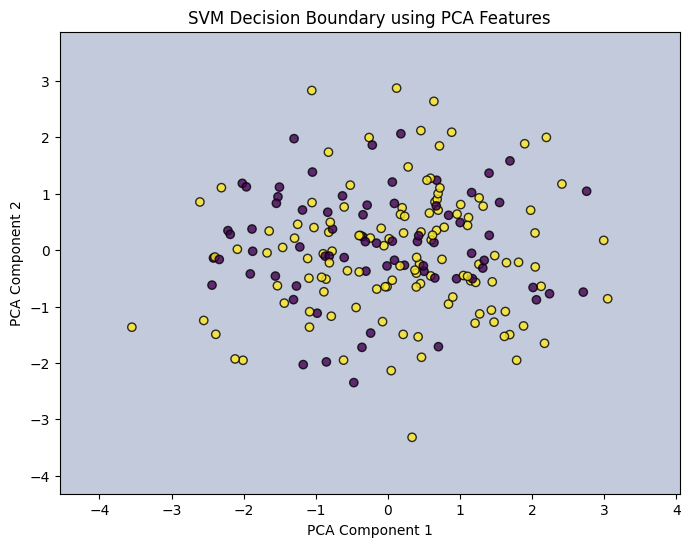

In [43]:
# Create mesh grid
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = svm_pca_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, edgecolors="k", alpha=0.8)
plt.title("SVM Decision Boundary using PCA Features")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# Task 6: Parameter Tuning and Optimization

We tune important SVM hyperparameters:

- `kernel`
- `C`
- `gamma`

`C` controls regularization.  
`gamma` controls the influence of individual training samples.

In [44]:
param_grid = {
    "kernel": ["linear", "rbf", "poly"],
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"]
}

grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

Best Cross Validation F1 Score:
0.5319


## 20. Tuned SVM Model Evaluation

In [45]:
best_svm_model = grid_search.best_estimator_

best_svm_pred = best_svm_model.predict(X_test_scaled)

results.append(evaluate_classifier(y_test, best_svm_pred, "Tuned SVM"))

Evaluation Metrics for Tuned SVM
---------------------------------------------
Accuracy : 0.5867
Precision: 0.5373
Recall   : 0.5867
F1 Score : 0.5421

Classification Report:
              precision    recall  f1-score   support

      edible       0.37      0.18      0.24        72
   poisonous       0.63      0.82      0.72       124

    accuracy                           0.59       196
   macro avg       0.50      0.50      0.48       196
weighted avg       0.54      0.59      0.54       196



## 21. Tuned SVM Confusion Matrix

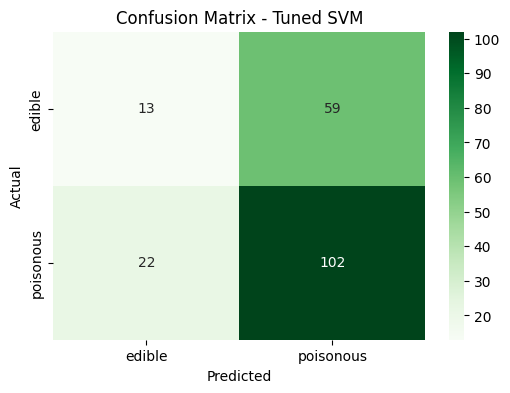

In [46]:
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, best_svm_pred),
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title("Confusion Matrix - Tuned SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Task 7: Comparison of SVM Kernels

We compare SVM performance using:

1. Linear Kernel  
2. Polynomial Kernel  
3. RBF Kernel

In [47]:
kernels = ["linear", "poly", "rbf"]

for kernel in kernels:
    model = SVC(kernel=kernel, C=1.0, gamma="scale", random_state=42)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    results.append(evaluate_classifier(y_test, pred, f"SVM Kernel - {kernel}"))

Evaluation Metrics for SVM Kernel - linear
---------------------------------------------
Accuracy : 0.5765
Precision: 0.5378
Recall   : 0.5765
F1 Score : 0.5453

Classification Report:
              precision    recall  f1-score   support

      edible       0.37      0.22      0.28        72
   poisonous       0.63      0.78      0.70       124

    accuracy                           0.58       196
   macro avg       0.50      0.50      0.49       196
weighted avg       0.54      0.58      0.55       196

Evaluation Metrics for SVM Kernel - poly
---------------------------------------------
Accuracy : 0.6327
Precision: 0.4002
Recall   : 0.6327
F1 Score : 0.4903

Classification Report:
              precision    recall  f1-score   support

      edible       0.00      0.00      0.00        72
   poisonous       0.63      1.00      0.78       124

    accuracy                           0.63       196
   macro avg       0.32      0.50      0.39       196
weighted avg       0.40      0.63

## 22. Model Comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Basic SVM - RBF Kernel,0.627551,0.399058,0.627551,0.487877
1,Tuned SVM,0.586735,0.537254,0.586735,0.542108
2,SVM Kernel - linear,0.576531,0.537781,0.576531,0.545304
3,SVM Kernel - poly,0.632653,0.400250,0.632653,0.490306
4,SVM Kernel - rbf,0.627551,0.399058,0.627551,0.487877


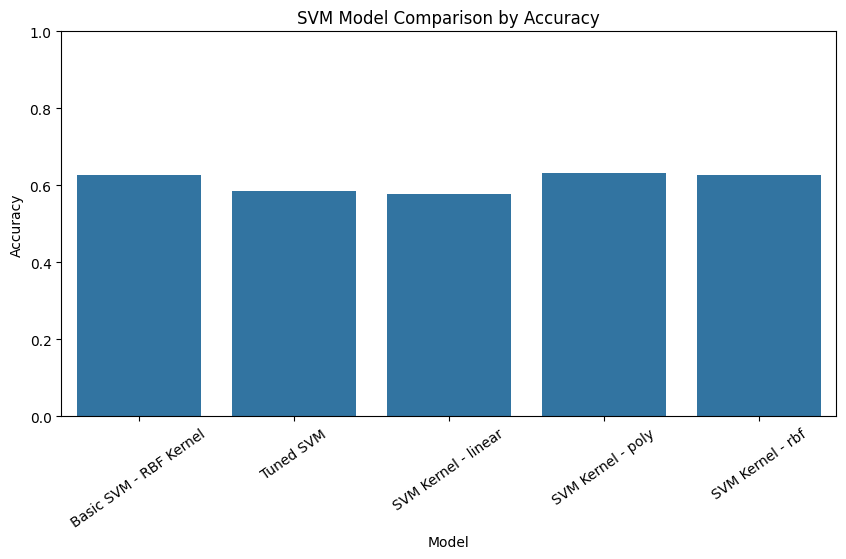

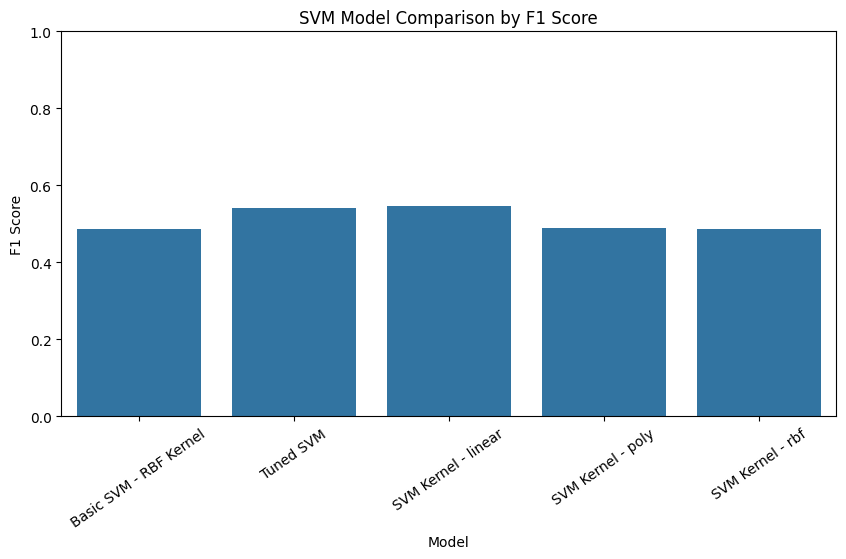

In [48]:
results_df = pd.DataFrame(results)

display(results_df)

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("SVM Model Comparison by Accuracy")
plt.xticks(rotation=35)
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Model", y="F1 Score")
plt.title("SVM Model Comparison by F1 Score")
plt.xticks(rotation=35)
plt.ylim(0, 1)
plt.show()

## 23. Analysis of SVM Strengths and Weaknesses

### Strengths of SVM

1. SVM works well for classification tasks.
2. It can handle high-dimensional data after encoding.
3. Kernel trick allows SVM to learn non-linear decision boundaries.
4. It is effective when classes are separable.
5. It can provide high accuracy on structured classification datasets.

### Weaknesses of SVM

1. SVM can be slow on very large datasets.
2. It requires feature scaling.
3. Choosing the correct kernel and parameters is important.
4. It is less interpretable compared to Decision Trees.
5. One-hot encoding can increase feature dimensions, making training heavier.

### For Mushroom Dataset

The Mushroom dataset mostly contains categorical features. After one-hot encoding, SVM can classify mushrooms effectively because categorical patterns can separate edible and poisonous classes.

## 24. Practical Implications of SVM

SVM is useful in real-world classification tasks such as:

1. Medical diagnosis
2. Spam detection
3. Text classification
4. Image classification
5. Fraud detection
6. Food safety classification

In this assignment, SVM helps classify mushrooms into categories based on their physical features. This shows how machine learning can support safety-related classification problems.

## 25. Final Conclusion

In this assignment, Support Vector Machine classification was applied to the Mushroom dataset. The dataset was explored using EDA, class distribution plots, categorical feature plots, numerical feature distributions, boxplots, and correlation heatmap.

Categorical variables were converted into numerical format using one-hot encoding. The dataset was split into training and testing sets, and feature scaling was applied before model training.

A basic SVM classifier was implemented and evaluated using accuracy, precision, recall, and F1-score. Classification results were visualized using PCA. Hyperparameter tuning was performed using GridSearchCV, and SVM models with linear, polynomial, and RBF kernels were compared.

The results show that SVM is a powerful classification algorithm, especially when proper preprocessing, scaling, and hyperparameter tuning are applied.